## 1. Criterios de éxito Sprint 1 vs Métricas Sprint 4

Los criterios de éxito definidos en el Sprint 1 coinciden con las métricas priorizadas en el Sprint 4, ya que ambos enfoques buscan evaluar si el modelo genera valor real para el negocio hotelero.

En el Sprint 1, el éxito del proyecto se definió en función de tres objetivos principales: detectar cancelaciones, reducir pérdidas económicas y activar acciones operativas. En el Sprint 4, estos objetivos se traducen en métricas concretas del modelo: **recall**, **F1-score** y **AUC-ROC**.

| Sprint 1: Criterio de éxito | Sprint 4: Métrica asociada | Coincidencia |
|---|---|---|
| Alcanzar un recall ≥ 80% | Recall | Permite detectar la mayor cantidad posible de reservas que realmente se cancelarán |
| Reducir pérdidas asociadas a cancelaciones y no-show | Recall | Reduce falsos negativos, es decir, cancelaciones reales no detectadas |
| Activar acciones preventivas sobre reservas riesgosas | Recall / F1-score | Permite intervenir reservas con alto riesgo sin generar demasiadas falsas alertas |
| Superar un modelo base o regla simple | Recall / F1-score / AUC-ROC | Demuestra que el modelo aporta más valor que una decisión manual o básica |
| Lograr un AUC ≥ 0.75 | AUC-ROC | Valida que el modelo discrimine correctamente entre reservas canceladas y no canceladas |

Por esta razón, los criterios de éxito del Sprint 1 y las métricas del Sprint 4 son consistentes: ambos priorizan la capacidad del modelo para anticipar cancelaciones y generar decisiones accionables para el negocio.

La priorización final de métricas queda de la siguiente manera:

| Prioridad | Métrica | Rol | Justificación |
|---:|---|---|---|
| 1 | Recall | Métrica principal | Reduce cancelaciones reales no detectadas |
| 2 | F1-score | Métrica secundaria | Balancea detección de cancelaciones y falsas alertas |
| 3 | AUC-ROC | Métrica de validación general | Evalúa la capacidad del modelo para separar reservas canceladas y no canceladas |
| 4 | Precision | Métrica de apoyo | Controla costos por intervenciones innecesarias |
| 5 | Accuracy | Métrica complementaria | Resume el acierto general, pero no diferencia el costo de cada error |

---

## 2. Matriz costo-beneficio: FP vs FN y beneficio de TP

Para evaluar el valor económico del modelo, se analiza el impacto de los principales resultados de clasificación: **True Positive (TP)**, **False Positive (FP)** y **False Negative (FN)**.

La lógica económica utilizada es la siguiente:

- Un **False Negative (FN)** es el error más costoso, porque el hotel no detecta una reserva que realmente se cancelará.
- Un **False Positive (FP)** genera un costo operativo, porque el hotel interviene una reserva que finalmente no se iba a cancelar.
- Un **True Positive (TP)** genera valor, porque permite anticipar una cancelación real y activar una acción preventiva.

### Supuestos económicos

| Concepto | Valor |
|---|---:|
| ADR promedio | 101.83 |
| Costo operativo estimado por falsa alerta | 5.00 |

El **ADR promedio** se usa como referencia del ingreso potencial por noche que podría perderse si una cancelación real no se detecta. El costo de falsa alerta representa acciones operativas como comunicación adicional, revisión administrativa, seguimiento comercial breve o registro de la alerta.

### Matriz costo-beneficio

| Resultado | Caso | Impacto operativo | Impacto económico estimado |
|---|---|---|---:|
| True Positive (TP) | El modelo predice cancelación y la reserva sí se cancela | Se activa una acción preventiva correctamente | Beneficio potencial: hasta 101.83 por noche protegida |
| False Negative (FN) | El modelo predice no cancelación, pero la reserva sí se cancela | No se toma acción preventiva | Costo potencial: 101.83 por noche perdida |
| False Positive (FP) | El modelo predice cancelación, pero la reserva no se cancela | Se interviene una reserva innecesariamente | Costo operativo: 5.00 por alerta |
| True Negative (TN) | El modelo predice no cancelación y la reserva no se cancela | No se interviene innecesariamente | Sin costo adicional |

### Comparación económica FP vs FN

| Tipo de error | Costo unitario estimado | Interpretación |
|---|---:|---|
| False Negative (FN) | 101.83 | Pérdida potencial por no anticipar una cancelación real |
| False Positive (FP) | 5.00 | Costo operativo por intervenir una reserva que no se iba a cancelar |

La diferencia entre ambos errores es significativa:

```text
Relación de costo FN vs FP = 101.83 / 5.00 = 20.37
```

Esto significa que, bajo estos supuestos, un **falso negativo puede ser aproximadamente 20 veces más costoso que un falso positivo**.

Por esta razón, el modelo debe priorizar el **recall**, ya que esta métrica reduce los falsos negativos. Sin embargo, también se considera el **F1-score** como métrica secundaria para evitar que el modelo genere demasiados falsos positivos y aumente innecesariamente los costos operativos.

## 3. Impacto económico anual del modelo

Para estimar el impacto económico anual del modelo, primero se anualizó la cantidad de reservas, ya que el dataset no contiene años completos para 2015 y 2017.

La proyección anual se calculó usando la siguiente fórmula:

```text
Proyección anual = promedio mensual de reservas × 12
```

### Proyección anual de reservas

| Año | Meses disponibles | Reservas observadas | Promedio mensual | Proyección anual |
|---:|---:|---:|---:|---:|
| 2015 | 6 | 21,996 | 3,666.00 | 43,992 |
| 2016 | 12 | 56,707 | 4,725.58 | 56,707 |
| 2017 | 8 | 40,687 | 5,085.88 | 61,030 |

Esta proyección permite comparar los años de forma más justa, ya que 2015 y 2017 tienen información parcial. En lugar de comparar directamente los totales observados, se usa una estimación anual basada en el promedio mensual de reservas.

---

### Modelo seleccionado para despliegue

El modelo final seleccionado para el despliegue es el **Tuned XGBoost del Sprint 4**.

| Métrica | Sprint 3 Baseline RF | Sprint 4 Tuned XGB | Mejora |
|---|---:|---:|---:|
| Recall | 0.769 | 0.775 | +0.8 pp |
| F1-score | 0.816 | 0.813 | -0.4 pp |
| AUC-ROC | 0.935 | 0.936 | +0.1 pp |
| Accuracy | 0.867 | 0.867 | +0.0 pp |

Aunque la mejora frente al baseline no es muy grande, el modelo Tuned XGB mantiene un desempeño alto y mejora ligeramente el **recall** y el **AUC-ROC**, que son métricas relevantes para detectar cancelaciones y validar la capacidad general de separación del modelo.

El **recall** es especialmente importante porque permite identificar una mayor proporción de reservas que realmente se cancelarán. En términos de negocio, esto aumenta la oportunidad de aplicar acciones preventivas antes de que la pérdida ocurra.

---

### Supuestos económicos

| Concepto | Valor |
|---|---:|
| Tasa de cancelación estimada | 37% |
| ADR promedio | 101.83 |
| Recall del modelo final | 0.775 |
| F1-score del modelo final | 0.813 |
| Precision estimada a partir de recall y F1-score | 0.855 |
| Costo operativo por falsa alerta | 5.00 |
| Efectividad base de acciones preventivas | 25% |

La efectividad de acciones preventivas se fija en **25%** como escenario base. Esto significa que no se asume que todas las cancelaciones detectadas se recuperan, sino que una parte de las reservas identificadas a tiempo puede convertirse en revenue protegido mediante acciones como confirmaciones, depósitos, campañas de retención u overbooking controlado.

Este supuesto se considera un escenario intermedio: no es tan conservador como asumir que casi ninguna alerta genera valor, pero tampoco asume que el hotel podrá recuperar la mayoría de cancelaciones detectadas.

| Escenario | Efectividad operativa | Interpretación |
|---|---:|---|
| Conservador | 10% | Solo una pequeña parte de las alertas se convierte en revenue recuperado |
| Base | 25% | Una parte razonable de las cancelaciones detectadas logra recuperarse o compensarse |
| Optimista | 40% | El hotel ejecuta muy bien las acciones preventivas y recupera más valor |

Para este análisis se usa el escenario **base de 25%**.

---

### Fórmulas de estimación

```text
Cancelaciones estimadas = reservas proyectadas × tasa de cancelación
```

```text
Cancelaciones detectadas = cancelaciones estimadas × recall
```

```text
Revenue en riesgo sin modelo = cancelaciones estimadas × ADR promedio
```

```text
Revenue recuperado = cancelaciones detectadas × ADR promedio × efectividad
```

```text
Falsas alertas estimadas = reservas marcadas como riesgo - cancelaciones detectadas
```

```text
Costo falsas alertas = falsas alertas estimadas × costo operativo por falsa alerta
```

```text
Ahorro neto = revenue recuperado - costo falsas alertas
```

```text
Pérdida residual con modelo = revenue en riesgo sin modelo - ahorro neto
```

---

### Impacto económico anual estimado

| Año | Reservas proyectadas | Cancelaciones estimadas | Revenue en riesgo sin modelo | Cancelaciones detectadas | Falsas alertas estimadas | Revenue recuperado 25% | Costo falsas alertas | Ahorro neto estimado |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 2015 | 43,992 | 16,277 | 1,657,491 | 12,615 | 2,141 | 321,139 | 10,704 | 310,435 |
| 2016 | 56,707 | 20,982 | 2,136,555 | 16,261 | 2,759 | 413,958 | 13,797 | 400,160 |
| 2017 | 61,030 | 22,581 | 2,299,433 | 17,500 | 2,970 | 445,515 | 14,849 | 430,666 |

Esta tabla muestra que el modelo no recupera todo el revenue en riesgo, pero sí permite capturar una parte relevante de las cancelaciones que antes no podían ser anticipadas. El ahorro neto descuenta el costo operativo generado por las falsas alertas.

---

### Comparación económica: sin modelo vs con modelo

En lugar de asumir que “sin modelo” equivale a cero, se considera que sin modelo existe una **pérdida potencial completa** asociada a las cancelaciones no anticipadas.

Con el modelo, parte de ese revenue puede recuperarse gracias a las acciones preventivas sobre las reservas detectadas como riesgosas.

| Año | Pérdida potencial sin modelo | Pérdida residual con modelo | Ahorro neto estimado |
|---:|---:|---:|---:|
| 2015 | 1,657,491 | 1,347,056 | 310,435 |
| 2016 | 2,136,555 | 1,736,395 | 400,160 |
| 2017 | 2,299,433 | 1,868,767 | 430,666 |

La columna **pérdida potencial sin modelo** representa el revenue en riesgo si el hotel no anticipa cancelaciones. La columna **pérdida residual con modelo** representa la pérdida que todavía permanece después de aplicar el modelo y descontar el ahorro neto generado.

---

### Nota sobre la pérdida residual con modelo

La efectividad operativa del **25%** significa que no todas las cancelaciones detectadas por el modelo se convertirán en revenue recuperado. Se asume que solo una parte de las reservas identificadas como riesgosas podrá ser retenida o compensada mediante acciones preventivas.

El **75% restante** corresponde a casos detectados que no logran recuperarse por distintos motivos operativos o comerciales.

| Motivo | Explicación |
|---|---|
| Decisión definitiva del cliente | El cliente ya decidió cancelar y no cambia su decisión aunque el hotel intervenga |
| Acción preventiva insuficiente | La confirmación, descuento, depósito o campaña no logra retener la reserva |
| Limitaciones operativas | El equipo no logra contactar o gestionar todos los casos detectados por el modelo |
| Cancelaciones inevitables | Algunas cancelaciones ocurren por motivos externos, como cambios de viaje, salud o imprevistos |
| Tiempo de reacción limitado | La alerta puede llegar tarde o la acción preventiva puede ejecutarse fuera del momento adecuado |

La pérdida residual con modelo no representa simplemente el 75% de la pérdida inicial. También incluye las cancelaciones que el modelo no detecta y las cancelaciones detectadas que no logran recuperarse mediante acciones operativas.

---

### Lectura ejecutiva del impacto económico

| Año | Revenue en riesgo sin modelo | Ahorro neto estimado | Reducción porcentual estimada |
|---:|---:|---:|---:|
| 2015 | 1,657,491 | 310,435 | 18.73% |
| 2016 | 2,136,555 | 400,160 | 18.73% |
| 2017 | 2,299,433 | 430,666 | 18.73% |

Bajo los supuestos del análisis, el modelo permitiría reducir aproximadamente **18.7% del revenue en riesgo** asociado a cancelaciones. Esta reducción proviene de detectar reservas con alta probabilidad de cancelación y convertir una parte de ellas en revenue recuperado o pérdida evitada.

---

### Interpretación de negocio

El modelo no elimina completamente las pérdidas por cancelaciones, pero permite reducirlas al identificar anticipadamente una parte importante de las reservas que tienen riesgo de cancelarse.

Bajo un escenario base de **25% de efectividad en acciones preventivas**, el modelo podría generar un ahorro neto anual estimado entre **310 mil y 431 mil unidades monetarias**, dependiendo del volumen anual proyectado de reservas.

Este resultado muestra que el valor del modelo no está solo en mejorar métricas técnicas, sino en convertir predicciones en acciones operativas que reduzcan pérdidas económicas.

,Año,Pérdida potencial sin modelo,Pérdida residual con modelo,Ahorro neto estimado
0,2015,1657491,1347056,310435
1,2016,2136555,1736395,400160
2,2017,2299433,1868767,430666


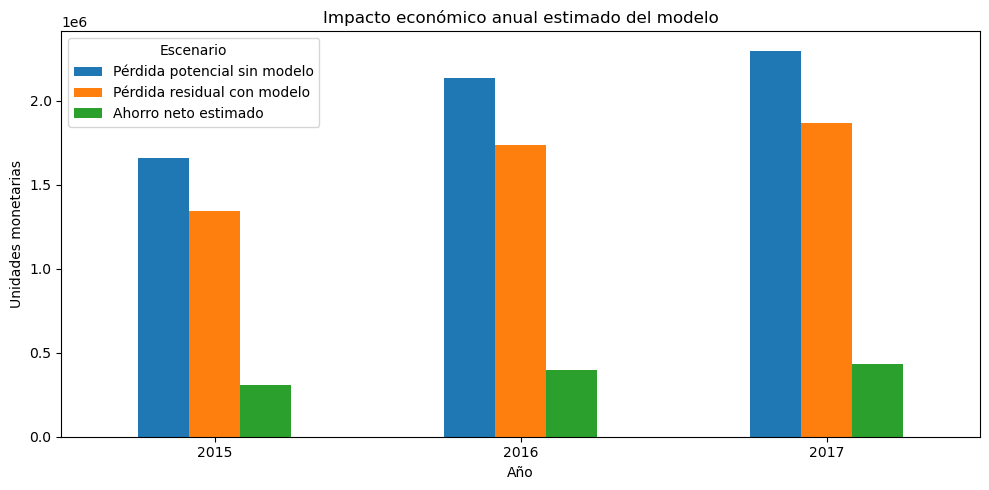

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

impacto = pd.DataFrame({
    "Año": [2015, 2016, 2017],
    "Pérdida potencial sin modelo": [1657491, 2136555, 2299433],
    "Pérdida residual con modelo": [1347056, 1736395, 1868767],
    "Ahorro neto estimado": [310435, 400160, 430666]
})

display(impacto)

ax = impacto.set_index("Año")[[
    "Pérdida potencial sin modelo",
    "Pérdida residual con modelo",
    "Ahorro neto estimado"
]].plot(kind="bar", figsize=(10, 5))

plt.title("Impacto económico anual estimado del modelo")
plt.xlabel("Año")
plt.ylabel("Unidades monetarias")
plt.xticks(rotation=0)
plt.legend(title="Escenario")
plt.tight_layout()
plt.show()

## 4. Gain curve y lift sobre baseline aleatoria

Para evaluar el valor operativo del modelo, se calcula la **gain curve** y el **lift acumulado** sobre una baseline aleatoria.

La **gain curve** muestra qué porcentaje de cancelaciones reales se logra capturar al revisar un determinado porcentaje de reservas ordenadas por riesgo. En este caso, las reservas se ordenan de mayor a menor probabilidad de cancelación estimada por el modelo final Tuned XGBoost.

El **lift acumulado** compara el desempeño del modelo contra una selección aleatoria. Un lift mayor a 1 indica que el modelo permite identificar cancelaciones mejor que revisar reservas al azar.

```text
Lift = % de cancelaciones capturadas / % de reservas revisadas

In [23]:
# ========================
# GAIN CURVE Y LIFT
# ========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gain_df = pd.DataFrame({
    "y_true": y_test,
    "y_proba": y_proba
})

# Ordenar reservas desde mayor hasta menor probabilidad de cancelación
gain_df = gain_df.sort_values("y_proba", ascending=False).reset_index(drop=True)

# Cálculos acumulados
gain_df["reservas_acum"] = np.arange(1, len(gain_df) + 1)
gain_df["cancelaciones_acum"] = gain_df["y_true"].cumsum()

total_reservas = len(gain_df)
total_cancelaciones = gain_df["y_true"].sum()

gain_df["pct_reservas_revisadas"] = gain_df["reservas_acum"] / total_reservas
gain_df["pct_cancelaciones_capturadas"] = gain_df["cancelaciones_acum"] / total_cancelaciones
gain_df["baseline_aleatoria"] = gain_df["pct_reservas_revisadas"]

# Lift acumulado
gain_df["lift"] = (
    gain_df["pct_cancelaciones_capturadas"] /
    gain_df["pct_reservas_revisadas"]
)

# Resumen por percentiles
percentiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

gain_summary = []

for p in percentiles:
    idx = int(np.ceil(p * total_reservas)) - 1
    row = gain_df.iloc[idx]

    gain_summary.append({
        "% reservas revisadas": f"{p:.0%}",
        "Reservas revisadas": int(row["reservas_acum"]),
        "Cancelaciones capturadas": int(row["cancelaciones_acum"]),
        "% cancelaciones capturadas": round(row["pct_cancelaciones_capturadas"] * 100, 2),
        "Baseline aleatoria (%)": round(p * 100, 2),
        "Lift": round(row["lift"], 2)
    })

gain_summary = pd.DataFrame(gain_summary)

display(gain_summary)

,% reservas revisadas,Reservas revisadas,Cancelaciones capturadas,% cancelaciones capturadas,Baseline aleatoria (%),Lift
0,5%,1193,1193,13.50,5.0,2.70
1,10%,2385,2385,26.98,10.0,2.70
2,20%,4769,4659,52.71,20.0,2.64
3,30%,7153,6381,72.19,30.0,2.41
4,40%,9537,7514,85.01,40.0,2.13
5,50%,11921,8148,92.18,50.0,1.84


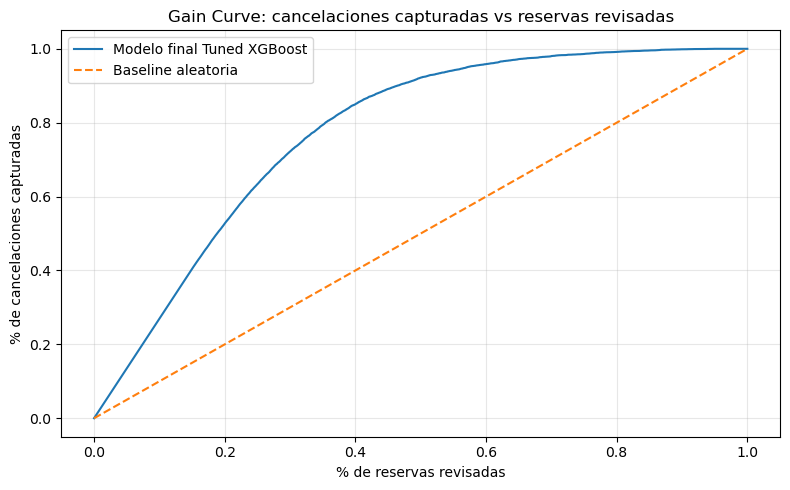

In [24]:
# ========================
# GRÁFICO GAIN CURVE
# ========================

plt.figure(figsize=(8, 5))

plt.plot(
    gain_df["pct_reservas_revisadas"],
    gain_df["pct_cancelaciones_capturadas"],
    label="Modelo final Tuned XGBoost"
)

plt.plot(
    gain_df["pct_reservas_revisadas"],
    gain_df["baseline_aleatoria"],
    linestyle="--",
    label="Baseline aleatoria"
)

plt.title("Gain Curve: cancelaciones capturadas vs reservas revisadas")
plt.xlabel("% de reservas revisadas")
plt.ylabel("% de cancelaciones capturadas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

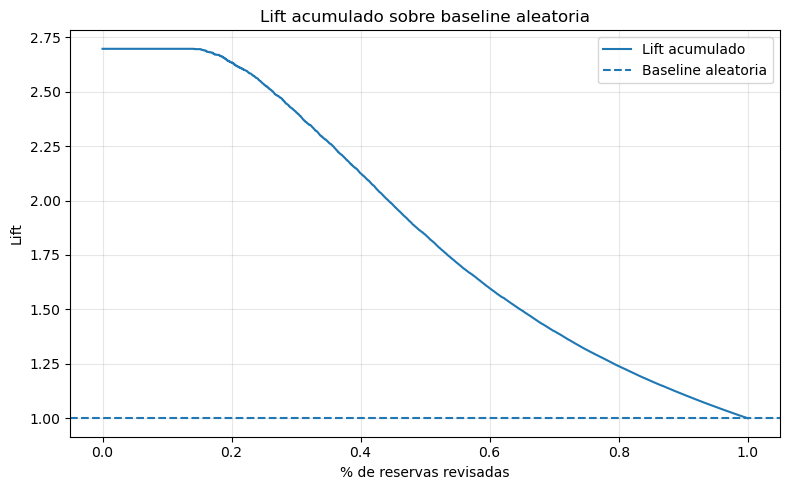

In [25]:
# ========================
# GRÁFICO LIFT ACUMULADO
# ========================

plt.figure(figsize=(8, 5))

plt.plot(
    gain_df["pct_reservas_revisadas"],
    gain_df["lift"],
    label="Lift acumulado"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Baseline aleatoria"
)

plt.title("Lift acumulado sobre baseline aleatoria")
plt.xlabel("% de reservas revisadas")
plt.ylabel("Lift")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de resultados

Los gráficos muestran que el modelo final tiene una capacidad clara para concentrar cancelaciones reales en los primeros segmentos de mayor riesgo.

En la **gain curve**, la curva del modelo se mantiene por encima de la baseline aleatoria. Esto significa que, al ordenar las reservas por probabilidad de cancelación, el modelo captura una mayor proporción de cancelaciones que una selección al azar.

En el gráfico de **lift acumulado**, el modelo presenta un lift alto en los primeros porcentajes de reservas revisadas y luego disminuye progresivamente hasta acercarse a 1 cuando se revisa el 100% de la base. Este comportamiento es esperado: el mayor valor del modelo está en los primeros segmentos, donde concentra las reservas con mayor riesgo.

Desde una perspectiva operativa, esto confirma que el hotel no necesita intervenir todas las reservas. Puede enfocar sus recursos en los grupos con mayor probabilidad de cancelación, aumentando la eficiencia de las acciones preventivas y reduciendo costos por intervenciones innecesarias.

En conclusión, la gain curve y el lift refuerzan el valor del modelo como herramienta de priorización: permite identificar antes las reservas con mayor riesgo y actuar sobre ellas de manera más eficiente que una estrategia aleatoria.

## 5. Umbral óptimo de decisión basado en valor esperado de negocio

El modelo final genera una probabilidad de cancelación para cada reserva. Para convertir esa probabilidad en una decisión operativa, se debe definir un **umbral de decisión**.

Por defecto, muchos modelos usan un umbral de **0.50**:

```text
Si probabilidad de cancelación ≥ 0.50 → predecir cancelación
Si probabilidad de cancelación < 0.50 → predecir no cancelación
```

Sin embargo, el umbral de **0.50** no necesariamente maximiza el valor de negocio. Ese umbral puede funcionar como referencia técnica, pero no siempre es el más adecuado cuando los costos de error son diferentes.

En este proyecto, el costo de un **falso negativo (FN)** es mayor que el costo de un **falso positivo (FP)**:

| Resultado | Caso | Impacto económico |
|---|---|---:|
| True Positive (TP) | El modelo detecta una cancelación real | Revenue recuperado esperado |
| False Positive (FP) | El modelo alerta una reserva que no iba a cancelar | Costo operativo innecesario |
| False Negative (FN) | El modelo no detecta una cancelación real | Pérdida no evitada |
| True Negative (TN) | El modelo no alerta una reserva que no iba a cancelar | Sin costo adicional |

Dado que no detectar una cancelación real puede representar una pérdida asociada al ADR, mientras que una falsa alerta solo genera un costo operativo menor, puede ser conveniente usar un umbral menor a 0.50. Esto permite detectar más cancelaciones reales, aunque aumenten algunas falsas alertas.

Para traducir esta lógica a valor económico, se utilizan los siguientes supuestos:

| Concepto | Valor |
|---|---:|
| ADR promedio | 101.83 |
| Efectividad operativa base | 25% |
| Revenue recuperado esperado por TP | 25.46 |
| Costo operativo por FP | 5.00 |

El revenue recuperado esperado por cada true positive se calcula como:

```text
Revenue recuperado por TP = ADR promedio × efectividad operativa
```

```text
Revenue recuperado por TP = 101.83 × 25% = 25.46
```

Por lo tanto, el valor esperado de negocio para cada umbral se calcula como:

```text
Valor esperado de negocio = (TP × revenue recuperado por TP) - (FP × costo operativo por FP)
```

Bajo esta lógica, se evalúan distintos umbrales posibles y se selecciona aquel que maximiza el valor esperado de negocio.

| Decisión sobre el umbral | Efecto esperado |
|---|---|
| Bajar el umbral | Aumenta el recall |
| Bajar el umbral | Se detectan más cancelaciones reales |
| Bajar el umbral | Disminuyen los falsos negativos |
| Bajar el umbral | Aumentan los falsos positivos y el costo operativo |
| Subir el umbral | Aumenta la precision de las alertas |
| Subir el umbral | Disminuye el costo por falsas alertas |
| Subir el umbral | Puede dejar más cancelaciones reales sin detectar |

La elección del umbral es una **decisión de negocio**, no solo una decisión técnica. El objetivo no es maximizar únicamente accuracy, sino encontrar el punto donde el revenue recuperado por cancelaciones detectadas compense mejor el costo operativo de las falsas alertas.

Por esta razón, se calcula y grafica el valor esperado de negocio para múltiples umbrales. La comparación entre el umbral estándar de **0.50** y el umbral óptimo permite justificar cuál decisión genera mayor valor económico para el hotel.

,Escenario,threshold,TP,FP,FN,TN,Precision,Recall,F1-score,Accuracy,Valor negocio test set
0,Umbral default 0.50,0.50,6853.0,1176.0,1986.0,13826.0,0.853531,0.775314,0.812544,0.867371,168580.2475
1,Umbral óptimo negocio,0.17,8155.0,3794.0,684.0,11208.0,0.682484,0.922616,0.784587,0.812172,188635.9125


,Año,Meses disponibles,Reservas observadas,Promedio mensual,Proyección anual,Factor escala vs test,Valor negocio anual proyectado
0,2015,6,21996,3666.00,43992,1.845225,348075.63
1,2016,12,56707,4725.58,56707,2.378550,448679.87
2,2017,8,40687,5085.88,61030,2.559876,482884.52


=== UMBRAL ÓPTIMO DE NEGOCIO ===
Reservas en test set: 23,841
Umbral óptimo: 0.17
Valor esperado de negocio en test set: 188,635.91
Recall: 0.9226
Precision: 0.6825
F1-score: 0.7846
Accuracy: 0.8122

=== PROYECCIÓN ANUAL DEL VALOR DE NEGOCIO ===
2015: 43,992 reservas proyectadas → 348,075.63
2016: 56,707 reservas proyectadas → 448,679.87
2017: 61,030 reservas proyectadas → 482,884.52


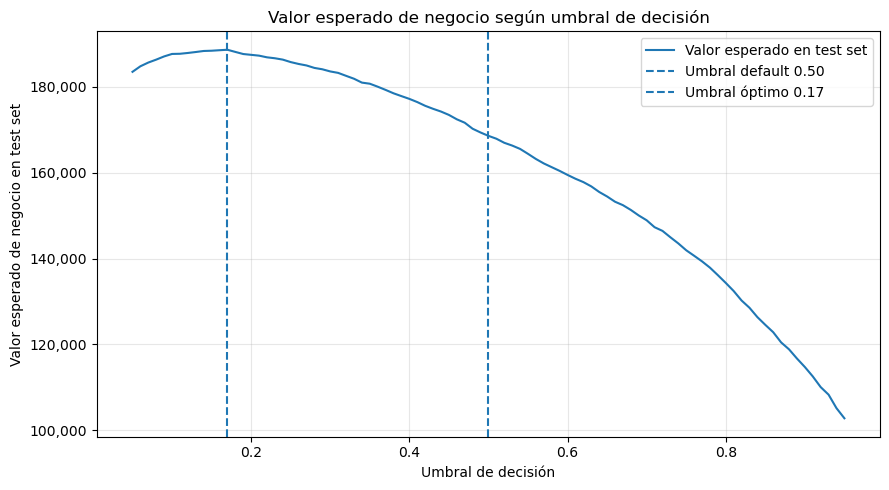

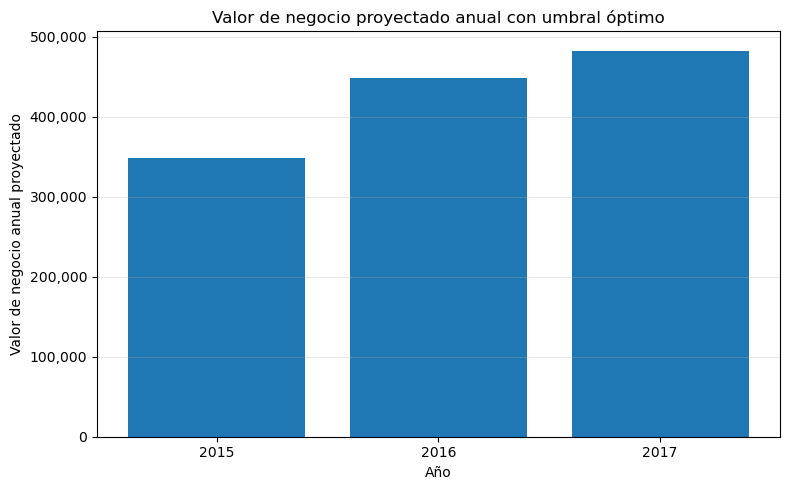

In [26]:
# ========================
# UMBRAL ÓPTIMO POR VALOR DE NEGOCIO
# ========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ========================
# Supuestos económicos
# ========================

ADR_PROMEDIO = 101.83
EFECTIVIDAD_OPERATIVA = 0.25
COSTO_FP = 5.00

BENEFICIO_TP = ADR_PROMEDIO * EFECTIVIDAD_OPERATIVA

# ========================
# Proyección anual de reservas
# ========================

proyeccion_anual = pd.DataFrame({
    "Año": [2015, 2016, 2017],
    "Meses disponibles": [6, 12, 8],
    "Reservas observadas": [21996, 56707, 40687],
    "Promedio mensual": [3666.00, 4725.58, 5085.88],
    "Proyección anual": [43992, 56707, 61030]
})

# ========================
# Evaluar umbrales en test set
# ========================

thresholds = np.arange(0.05, 0.96, 0.01)

resultados_umbral = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    valor_negocio_test = (tp * BENEFICIO_TP) - (fp * COSTO_FP)
    
    resultados_umbral.append({
        "threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Valor negocio test set": valor_negocio_test
    })

resultados_umbral = pd.DataFrame(resultados_umbral)

# ========================
# Identificar umbral óptimo
# ========================

idx_best = resultados_umbral["Valor negocio test set"].idxmax()
best_threshold_row = resultados_umbral.loc[idx_best]
best_threshold = best_threshold_row["threshold"]

# Comparar contra umbral default 0.50
default_row = resultados_umbral.iloc[
    (resultados_umbral["threshold"] - 0.50).abs().argsort()[:1]
]

comparacion_umbral = pd.concat([
    default_row.assign(Escenario="Umbral default 0.50"),
    best_threshold_row.to_frame().T.assign(Escenario="Umbral óptimo negocio")
], ignore_index=True)

comparacion_umbral = comparacion_umbral[
    [
        "Escenario",
        "threshold",
        "TP",
        "FP",
        "FN",
        "TN",
        "Precision",
        "Recall",
        "F1-score",
        "Accuracy",
        "Valor negocio test set"
    ]
]

display(comparacion_umbral)

# ========================
# Escalar valor del test set a proyección anual
# ========================

reservas_test = len(y_test)
valor_test_optimo = best_threshold_row["Valor negocio test set"]

proyeccion_valor_anual = proyeccion_anual.copy()

proyeccion_valor_anual["Factor escala vs test"] = (
    proyeccion_valor_anual["Proyección anual"] / reservas_test
)

proyeccion_valor_anual["Valor negocio anual proyectado"] = (
    valor_test_optimo * proyeccion_valor_anual["Factor escala vs test"]
).round(2)

proyeccion_valor_anual["Valor negocio anual proyectado"] = (
    proyeccion_valor_anual["Valor negocio anual proyectado"]
)

display(proyeccion_valor_anual)

# ========================
# Imprimir resumen
# ========================

print("=== UMBRAL ÓPTIMO DE NEGOCIO ===")
print(f"Reservas en test set: {reservas_test:,}")
print(f"Umbral óptimo: {best_threshold:.2f}")
print(f"Valor esperado de negocio en test set: {valor_test_optimo:,.2f}")
print(f"Recall: {best_threshold_row['Recall']:.4f}")
print(f"Precision: {best_threshold_row['Precision']:.4f}")
print(f"F1-score: {best_threshold_row['F1-score']:.4f}")
print(f"Accuracy: {best_threshold_row['Accuracy']:.4f}")

print()
print("=== PROYECCIÓN ANUAL DEL VALOR DE NEGOCIO ===")
for _, row in proyeccion_valor_anual.iterrows():
    print(
        f"{int(row['Año'])}: "
        f"{int(row['Proyección anual']):,} reservas proyectadas → "
        f"{row['Valor negocio anual proyectado']:,.2f}"
    )

# ========================
# Gráfico 1: valor de negocio por umbral en test set
# ========================

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    resultados_umbral["threshold"],
    resultados_umbral["Valor negocio test set"],
    label="Valor esperado en test set"
)

ax.axvline(
    x=0.50,
    linestyle="--",
    label="Umbral default 0.50"
)

ax.axvline(
    x=best_threshold,
    linestyle="--",
    label=f"Umbral óptimo {best_threshold:.2f}"
)

ax.set_title("Valor esperado de negocio según umbral de decisión")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Valor esperado de negocio en test set")
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()

# ========================
# Gráfico 2: proyección anual del valor de negocio
# ========================

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    proyeccion_valor_anual["Año"].astype(str),
    proyeccion_valor_anual["Valor negocio anual proyectado"]
)

ax.set_title("Valor de negocio proyectado anual con umbral óptimo")
ax.set_xlabel("Año")
ax.set_ylabel("Valor de negocio anual proyectado")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusión del umbral óptimo

El umbral que maximiza el valor esperado de negocio en el **test set** es **0.17**, con un valor estimado de **188,635.91** sobre **23,841 reservas evaluadas**.

Este resultado muestra que el umbral estándar de **0.50** no es el más adecuado para el objetivo del negocio. Al reducir el umbral a **0.17**, el modelo aumenta el **recall a 0.9226**, lo que permite detectar más reservas que realmente se cancelarán.

Aunque la precision baja a **0.6825** y aumentan las falsas alertas, el impacto económico sigue siendo favorable porque el costo de no detectar una cancelación real es mayor que el costo operativo de intervenir una reserva que finalmente no se cancela.

El valor de **188,635.91** corresponde solo al test set. Para hacerlo comparable con el impacto anual, se escala según la cantidad proyectada de reservas:

**Valor anual proyectado = valor en test set × (reservas anuales proyectadas / reservas en test set)**

En conclusión, el umbral óptimo debe elegirse como una **decisión de negocio**, priorizando el valor económico esperado y no únicamente métricas técnicas como accuracy.

## 6. Supuestos, fuentes de costos y análisis de sensibilidad

El impacto económico estimado del modelo depende de varios supuestos de negocio. Por ello, es importante documentar claramente qué valores fueron utilizados, de dónde provienen y cómo podrían cambiar los resultados si estos supuestos varían.

El objetivo de esta sección es transparentar que el valor económico calculado no es un resultado absoluto, sino una **estimación basada en supuestos razonables** sobre el comportamiento del negocio hotelero.

---

### 6.1 Supuestos principales del análisis

| Supuesto | Valor usado | Fuente o justificación |
|---|---:|---|
| Tasa de cancelación | 37% | Estimada a partir de la media de la variable `is_canceled` |
| ADR promedio | 101.83 | Promedio observado de la variable `ADR` |
| Recall del modelo final | 0.7753 | Resultado del modelo Tuned XGBoost en test set |
| F1-score del modelo final | 0.8125 | Resultado del modelo Tuned XGBoost en test set |
| AUC-ROC del modelo final | 0.9357 | Resultado del modelo Tuned XGBoost en test set |
| Precision del modelo final | 0.8535 | Resultado del modelo Tuned XGBoost en test set |
| Costo operativo por falsa alerta | 5.00 | Supuesto operativo basado en acciones de seguimiento |
| Efectividad operativa base | 25% | Supuesto de negocio sobre recuperación de revenue detectado |
| Umbral óptimo de negocio | 0.17 | Calculado maximizando el valor esperado de negocio |

---

### 6.2 Fuentes de los costos utilizados

El análisis económico utiliza dos componentes principales de valor:

1. **Revenue en riesgo por cancelaciones no detectadas.**
2. **Costo operativo por falsas alertas.**

El revenue en riesgo se aproxima usando el **ADR promedio**, ya que esta variable representa el ingreso promedio diario por habitación ocupada.

```text
Revenue en riesgo por cancelación ≈ ADR promedio
```

El costo operativo por falsa alerta se estima en **5.00 unidades monetarias**. Este valor representa un costo promedio asociado a acciones que el equipo operativo o comercial podría realizar sobre reservas marcadas como riesgosas.

| Componente operativo | Costo estimado |
|---|---:|
| Envío de comunicación adicional | 0.50 |
| Revisión administrativa de la alerta | 1.00 |
| Seguimiento comercial o llamada breve | 2.00 |
| Registro y monitoreo de la alerta | 0.50 |
| Posible incentivo menor o gestión adicional | 1.00 |
| **Costo total estimado por falsa alerta** | **5.00** |

Este costo no representa una medición contable exacta, sino un supuesto operativo para estimar el orden de magnitud del impacto económico.

---

### 6.3 Justificación del supuesto de efectividad operativa

La efectividad operativa representa el porcentaje del revenue asociado a cancelaciones detectadas que puede recuperarse o compensarse mediante acciones preventivas.

En este análisis se utiliza un escenario base de **25%**.

Esto no significa que el modelo evita el 25% de todas las cancelaciones. Significa que, de las cancelaciones detectadas por el modelo, se asume que una parte puede convertirse en revenue recuperado o pérdida evitada.

| Escenario | Efectividad operativa | Interpretación |
|---|---:|---|
| Conservador | 10% | Pocas alertas logran convertirse en revenue recuperado |
| Base | 25% | Una parte razonable de las alertas genera valor operativo |
| Optimista | 40% | El hotel ejecuta muy bien las acciones preventivas |

El escenario base de **25%** se considera razonable porque no todas las cancelaciones pueden evitarse. Algunas dependen de decisiones definitivas del cliente, cambios de viaje, motivos personales o limitaciones operativas. Sin embargo, una parte sí puede gestionarse mediante confirmaciones anticipadas, políticas de depósito, campañas de retención u overbooking controlado.

---

### 6.4 Rangos de sensibilidad propuestos

Para evaluar la robustez del análisis, se proponen rangos de sensibilidad sobre las variables económicas más importantes.

| Variable | Valor conservador | Valor base | Valor optimista |
|---|---:|---:|---:|
| Efectividad operativa | 10% | 25% | 40% |
| Costo por falsa alerta | 3.00 | 5.00 | 8.00 |
| ADR usado para estimación | 94.58 | 101.83 | 126.00 |

La variable más importante para el impacto económico es la **efectividad operativa**, porque determina qué proporción del revenue detectado puede convertirse realmente en ahorro o ingreso recuperado.

El costo por falsa alerta también es relevante, pero su impacto es menor que el costo de no detectar cancelaciones reales, especialmente porque el ADR promedio es considerablemente mayor que el costo operativo unitario asumido.

---

### 6.5 Matriz de sensibilidad sugerida

La siguiente matriz permite interpretar cómo cambiaría el valor del modelo bajo distintos escenarios de efectividad operativa y costo por falsa alerta.

| Escenario | Efectividad | Costo FP | Interpretación esperada |
|---|---:|---:|---|
| Conservador | 10% | 8.00 | Menor beneficio neto; útil para evaluar el peor caso razonable |
| Base | 25% | 5.00 | Escenario principal del análisis |
| Optimista | 40% | 3.00 | Mayor beneficio neto; supone buena ejecución operativa |

Esta sensibilidad es importante porque el valor del modelo no depende únicamente de su desempeño técnico, sino también de la capacidad del negocio para convertir predicciones en acciones efectivas.

---

### 6.6 Conclusión

Los resultados económicos del modelo deben interpretarse como una **estimación de valor esperado**, no como una garantía de ahorro exacto.

Los principales supuestos utilizados son:

| Supuesto clave | Rol en el análisis |
|---|---|
| ADR promedio | Aproxima el revenue en riesgo por cancelación |
| Costo por falsa alerta | Estima el costo operativo de intervenir reservas innecesariamente |
| Efectividad operativa | Estima qué parte de las cancelaciones detectadas puede convertirse en revenue recuperado |
| Recall del modelo | Determina cuántas cancelaciones reales logra detectar el modelo |
| Umbral de decisión | Define el balance entre detectar más cancelaciones y generar más falsas alertas |

Documentar estos supuestos permite que el análisis sea transparente, ajustable y defendible. Si el negocio obtiene mejores datos de costos reales o tasas de recuperación, los cálculos pueden actualizarse sin cambiar la lógica general del modelo.

In [30]:
# ========================
# ANÁLISIS DE SENSIBILIDAD CON NOMBRES DE NEGOCIO
# ========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import confusion_matrix

# ========================
# 1. Parámetros base
# ========================

# Usar el umbral óptimo encontrado en el punto 5
threshold_negocio = best_threshold

# Predicciones con umbral óptimo
y_pred_business = (y_proba >= threshold_negocio).astype(int)

# Matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_business).ravel()

# Supuestos económicos
ADR_PROMEDIO = 101.83

efectividades = [0.10, 0.25, 0.40]
costos_fp = [3.00, 5.00, 8.00]

# ========================
# 2. Calcular sensibilidad
# ========================

sensibilidad = []

for efectividad in efectividades:
    for costo_fp in costos_fp:
        beneficio_tp = ADR_PROMEDIO * efectividad
        valor_negocio = (tp * beneficio_tp) - (fp * costo_fp)
        
        sensibilidad.append({
            "% cancelaciones detectadas recuperadas": f"{efectividad:.0%}",
            "Costo por falsa alerta": costo_fp,
            "Cancelaciones detectadas correctamente": tp,
            "Falsas alertas": fp,
            "Revenue recuperado por cancelación detectada": round(beneficio_tp, 2),
            "Ahorro neto esperado": round(valor_negocio, 2)
        })

sensibilidad_df = pd.DataFrame(sensibilidad)

# Mostrar tabla principal con separador de miles
display(
    sensibilidad_df.style.format({
        "Costo por falsa alerta": "{:,.2f}",
        "Cancelaciones detectadas correctamente": "{:,.0f}",
        "Falsas alertas": "{:,.0f}",
        "Revenue recuperado por cancelación detectada": "{:,.2f}",
        "Ahorro neto esperado": "{:,.2f}"
    })
)

# ========================
# 3. Crear tabla pivote para lectura rápida
# ========================

sensibilidad_pivot = sensibilidad_df.pivot(
    index="% cancelaciones detectadas recuperadas",
    columns="Costo por falsa alerta",
    values="Ahorro neto esperado"
)

# Quitar decimales innecesarios en los encabezados de costo
sensibilidad_pivot.columns = [
    f"{int(col)}" if float(col).is_integer() else f"{col:g}"
    for col in sensibilidad_pivot.columns
]

# Mostrar tabla pivote con separador de miles
display(
    sensibilidad_pivot.style.format("{:,.2f}")
)

,% cancelaciones detectadas recuperadas,Costo por falsa alerta,Cancelaciones detectadas correctamente,Falsas alertas,Revenue recuperado por cancelación detectada,Ahorro neto esperado
0,10%,3.00,"8,155","3,794",10.18,"71,660.37"
1,10%,5.00,"8,155","3,794",10.18,"64,072.37"
2,10%,8.00,"8,155","3,794",10.18,"52,690.37"
3,25%,3.00,"8,155","3,794",25.46,"196,223.91"
4,25%,5.00,"8,155","3,794",25.46,"188,635.91"
5,25%,8.00,"8,155","3,794",25.46,"177,253.91"
6,40%,3.00,"8,155","3,794",40.73,"320,787.46"
7,40%,5.00,"8,155","3,794",40.73,"313,199.46"
8,40%,8.00,"8,155","3,794",40.73,"301,817.46"


,3,5,8
% cancelaciones detectadas recuperadas,,,
10%,"71,660.37","64,072.37","52,690.37"
25%,"196,223.91","188,635.91","177,253.91"
40%,"320,787.46","313,199.46","301,817.46"


## Conclusión general

El análisis de valor de negocio permitió conectar las métricas del modelo con decisiones económicas y operativas del hotel.

Los criterios de éxito del **Sprint 1** son coherentes con las métricas del **Sprint 4**: se prioriza el **recall** para detectar cancelaciones reales, el **F1-score** para controlar falsas alertas y el **AUC-ROC** para validar la capacidad general del modelo.

La matriz costo-beneficio mostró que un **falso negativo** es más costoso que un **falso positivo**, porque implica no detectar una cancelación real y perder la oportunidad de actuar. Por ello, el modelo debe priorizar la detección de cancelaciones.

El análisis económico anual, la gain curve, el lift y el umbral óptimo muestran que el modelo puede generar valor al priorizar reservas de mayor riesgo y apoyar acciones preventivas. Además, el umbral óptimo de **0.17** confirma que la decisión final debe basarse en valor de negocio, no solo en accuracy.

En conclusión, el modelo tiene potencial para reducir pérdidas por cancelaciones, mejorar la priorización operativa y convertir predicciones en acciones concretas como confirmaciones, campañas de retención, depósitos u overbooking controlado.